In [39]:
import json
import cv2
import shutil
import numpy as np
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.patches as patches


In [42]:
# Configure folders for splitting the labeled images.  Break panoramic images into tiles for better performance.
# --- CONFIG ---
project_root = Path.cwd().parent  # go up from 'code' → project root
splits_dir = project_root / "data" / "cvat_out_coco" / "splits"
output_dir = project_root / "data" / "cvat_out_coco" / "splits_tiled"
output_dir.mkdir(parents=True, exist_ok=True)

tile_w, tile_h = 376, 180
overlap_px = int(tile_w * 0.20)  # 20% overlap
step_x = tile_w - overlap_px
num_tiles = 4

splits = ["train", "val", "test"]

# --- Helper: split boxes into tiles ---
def split_annotations(img_info, anns, tile_idx, x0):
    new_anns = []
    for ann in anns:
        x, y, w, h = ann["bbox"]
        x2, y2 = x + w, y + h

        # overlap check with current tile bounds
        if x2 < x0 or x > x0 + tile_w:
            continue  # completely outside tile

        # crop box within tile bounds
        new_x1 = max(x - x0, 0)
        new_x2 = min(x2 - x0, tile_w)
        new_w = new_x2 - new_x1
        if new_w <= 1:
            continue

        ann_new = ann.copy()
        ann_new["bbox"] = [new_x1, y, new_w, h]
        new_anns.append(ann_new)
    return new_anns



In [43]:
# Do the splitting of into train / test / val & tiles for each
# --- Main loop ---
for split in splits:
    print(f"\nProcessing {split} set...")

    in_json = splits_dir / f"instances_{split}.json"
    with open(in_json) as f:
        coco = json.load(f)

    img_dir = splits_dir / split
    out_img_dir = output_dir / split
    out_img_dir.mkdir(parents=True, exist_ok=True)

    new_coco = {k: coco[k] for k in ["info", "licenses", "categories"] if k in coco}
    new_coco["images"], new_coco["annotations"] = [], []

    ann_id = 1
    img_id = 1

    id_to_anns = {}
    for ann in coco["annotations"]:
        id_to_anns.setdefault(ann["image_id"], []).append(ann)

    for img_info in tqdm(coco["images"]):
        img_path = img_dir / img_info["file_name"]
        img = cv2.imread(str(img_path))
        if img is None:
            print(f"⚠️ Skipping missing image: {img_path}")
            continue

        # tile horizontally
        for i in range(num_tiles):
            x0 = i * step_x
            x1 = x0 + tile_w
            if x1 > img.shape[1]:
                x1 = img.shape[1]
                x0 = x1 - tile_w

            tile = img[0:tile_h, x0:x1]
            tile_name = f"{Path(img_info['file_name']).stem}_tile{i}.jpg"
            tile_path = out_img_dir / tile_name
            cv2.imwrite(str(tile_path), tile)

            anns = id_to_anns.get(img_info["id"], [])
            new_anns = split_annotations(img_info, anns, i, x0)

            new_coco["images"].append({
                "id": img_id,
                "width": tile_w,
                "height": tile_h,
                "file_name": tile_name
            })

            for ann in new_anns:
                ann_copy = ann.copy()
                ann_copy["id"] = ann_id
                ann_copy["image_id"] = img_id
                new_coco["annotations"].append(ann_copy)
                ann_id += 1

            img_id += 1

    out_json = output_dir / f"instances_{split}.json"
    with open(out_json, "w") as f:
        json.dump(new_coco, f, indent=2)

    print(f"✅ Saved {len(new_coco['images'])} images and {len(new_coco['annotations'])} annotations to {out_json}")


Processing train set...


100%|██████████| 32/32 [00:00<00:00, 376.06it/s]


✅ Saved 128 images and 1268 annotations to /Users/jfs-m3/Documents/DS/sum-surfers/data/cvat_out_coco/splits_tiled/instances_train.json

Processing val set...


100%|██████████| 15/15 [00:00<00:00, 470.55it/s]


✅ Saved 60 images and 356 annotations to /Users/jfs-m3/Documents/DS/sum-surfers/data/cvat_out_coco/splits_tiled/instances_val.json

Processing test set...


100%|██████████| 10/10 [00:00<00:00, 509.48it/s]

✅ Saved 40 images and 188 annotations to /Users/jfs-m3/Documents/DS/sum-surfers/data/cvat_out_coco/splits_tiled/instances_test.json


In [44]:
# Function to preview labeled data (images + bounding boxes); click repeatedly to get next image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2
import json
from pathlib import Path

# --- Generator builder ---
def tiled_row_generator(split="train"):
    """
    Builds a generator that yields 4-tile sets from the chosen split.
    """
    split_dir = output_dir / split
    json_path = split_dir.parent / f"instances_{split}.json"
    
    with open(json_path) as f:
        coco = json.load(f)

    # Index COCO data
    img_lookup = {Path(i["file_name"]).stem: i for i in coco["images"]}
    anns_by_img = {}
    for a in coco["annotations"]:
        anns_by_img.setdefault(a["image_id"], []).append(a)

    # Build list of base image names (everything before "_tile#")
    base_names = sorted({name.rsplit("_tile", 1)[0] for name in img_lookup})
    print(f"Found {len(base_names)} base images in '{split}' split.")

    for base_name in base_names:
        # collect 4 tiles
        tile_infos = []
        for i in range(4):
            tile_name = f"{base_name}_tile{i}"
            if tile_name in img_lookup:
                tile_infos.append(img_lookup[tile_name])
        yield base_name, tile_infos, anns_by_img, split_dir


# --- Persistent generator state ---
_generators = {}

def show_tiled_row(folder="train"):
    """
    Displays the next 4 cropped tiles from the next base image in the folder.
    """
    if folder not in _generators:
        _generators[folder] = tiled_row_generator(folder)

    try:
        base_name, tile_infos, anns_by_img, img_dir = next(_generators[folder])
    except StopIteration:
        print(f"✅ Reached end of '{folder}' split.")
        _generators[folder] = tiled_row_generator(folder)  # restart
        base_name, tile_infos, anns_by_img, img_dir = next(_generators[folder])
        print(f"🔄 Restarting from beginning of '{folder}' split.")

    # --- Plot ---
    fig, axes = plt.subplots(1, 4, figsize=(16, 5))
    plt.subplots_adjust(wspace=0.05)
    fig.suptitle(f"{folder.upper()} — {base_name}", fontsize=12)

    for i, img_info in enumerate(tile_infos):
        img_path = img_dir / img_info["file_name"]
        img = cv2.imread(str(img_path))
        if img is None:
            axes[i].axis("off")
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[i].imshow(img)
        axes[i].axis("off")

        for ann in anns_by_img.get(img_info["id"], []):
            x, y, w, h = ann["bbox"]
            rect = patches.Rectangle(
                (x, y), w, h,
                linewidth=1.2,
                edgecolor=(1, 0, 0, 0.5),
                facecolor=(1, 0, 0, 0.15)
            )
            axes[i].add_patch(rect)
            ## Include a label
            # axes[i].text(
            #     x, y - 2, "surfer",
            #     color=(1, 0, 0, 0.6),
            #     fontsize=7,
            #     backgroundcolor=(1, 1, 1, 0.3)
            # )

    plt.show()

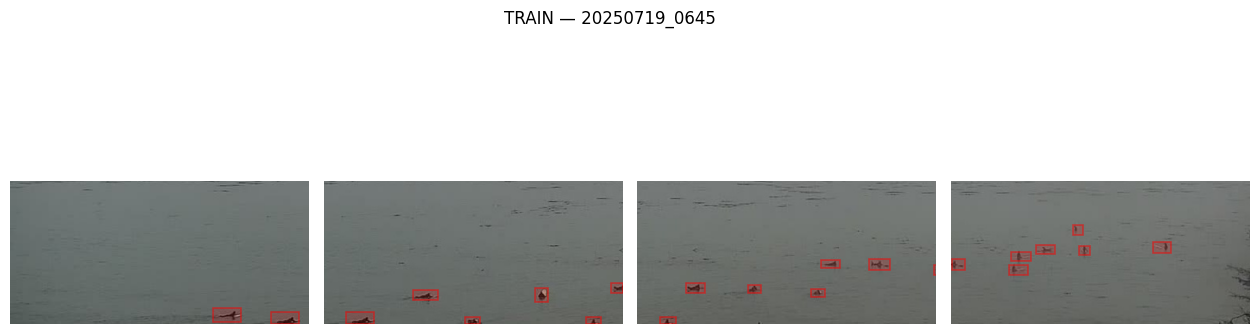

In [46]:
# Calling preview function
show_tiled_row("train")  # call multiple times to see more rows

In [ ]:
# --- Install YOLOv8 ---
# !pip install ultralytics --quiet

from ultralytics import YOLO
from pathlib import Path
import matplotlib.pyplot as plt
import cv2
import os

In [18]:
# --- Define project root and paths ---
project_root = Path.cwd()
data_dir = project_root.parent / "data" / "cvat_out_coco" / "splits"

print("Project root:", project_root)
print("Data folder:", data_dir)

# --- Verify subfolders and jsons exist ---
for sub in ["train", "val", "test"]:
    folder = data_dir / sub
    print(sub, "->", len(list(folder.glob("*.jpg"))), "images")

for json_file in data_dir.glob("*.json"):
    print("JSON:", json_file.name)

Project root: /Users/jfs-m3/Documents/DS/sum-surfers/code
Data folder: /Users/jfs-m3/Documents/DS/sum-surfers/data/cvat_out_coco/splits
train -> 32 images
val -> 15 images
test -> 10 images
JSON: instances_test.json
JSON: instances_train.json
JSON: instances_val.json


In [ ]:
# Converting coco data to Yolo for modeling
import json
from pathlib import Path
import shutil

# --- setup paths ---
cwd = Path.cwd()
project_root = cwd.parent if cwd.name == "code" else cwd
print("project_root:", project_root)

coco_root = project_root / "data" / "cvat_out_coco" / "splits_tiled"
yolo_root = project_root / "data" / "cvat_out_yolo_rebuilt"

# Create YOLO folder structure
for split in ["train", "val", "test"]:
    (yolo_root / "images" / split).mkdir(parents=True, exist_ok=True)
    (yolo_root / "labels" / split).mkdir(parents=True, exist_ok=True)

# --- helper: convert coco bbox -> yolo bbox ---
def coco_to_yolo_bbox(bbox, img_w, img_h):
    # COCO: [x_min, y_min, width, height]
    x, y, w, h = bbox
    x_c = (x + w / 2) / img_w
    y_c = (y + h / 2) / img_h
    w_n = w / img_w
    h_n = h / img_h
    return [x_c, y_c, w_n, h_n]

# --- process each split ---
for split in ["train", "val", "test"]:
    json_path = coco_root / f"instances_{split}.json"
    if not json_path.exists():
        print(f"⚠️ Missing {json_path}")
        continue

    with open(json_path, "r") as f:
        coco_data = json.load(f)

    # map image_id -> (file_name, width, height)
    id_to_info = {img["id"]: img for img in coco_data["images"]}
    print(f"\nProcessing {split}: {len(id_to_info)} images")

    # group annotations by image_id
    img_to_anns = {img_id: [] for img_id in id_to_info.keys()}
    for ann in coco_data["annotations"]:
        img_to_anns[ann["image_id"]].append(ann)

    copied_images, made_labels = 0, 0

    # loop over images in JSON
    for img_id, info in id_to_info.items():
        file_name = info["file_name"]
        src_img = coco_root / split / file_name
        dst_img = yolo_root / "images" / split / file_name
        dst_lbl = yolo_root / "labels" / split / (Path(file_name).stem + ".txt")

        if not src_img.exists():
            print(f"⚠️ missing image: {src_img}")
            continue

        # copy image
        shutil.copy2(src_img, dst_img)
        copied_images += 1

        # write YOLO label file
        anns = img_to_anns.get(img_id, [])
        with open(dst_lbl, "w") as f_out:
            for ann in anns:
                cls = ann["category_id"] - 1  # YOLO classes start at 0
                bbox_yolo = coco_to_yolo_bbox(ann["bbox"], info["width"], info["height"])
                f_out.write(f"{cls} " + " ".join(f"{x:.6f}" for x in bbox_yolo) + "\n")
        made_labels += 1

    print(f"✅ {split}: {copied_images} images copied, {made_labels} labels created")

# --- write YOLO data.yaml ---
data_yaml = f"""
train: {yolo_root}/images/train
val: {yolo_root}/images/val
test: {yolo_root}/images/test

nc: 1
names: ['Surfer']
"""

yaml_path = yolo_root / "data.yaml"
yaml_path.write_text(data_yaml.strip())
print(f"\n✅ Wrote {yaml_path}")

project_root: /Users/jfs-m3/Documents/DS/sum-surfers

Processing train: 128 images
✅ train: 128 images copied, 128 labels created

Processing val: 60 images
✅ val: 60 images copied, 60 labels created

Processing test: 40 images
✅ test: 40 images copied, 40 labels created

✅ Wrote /Users/jfs-m3/Documents/DS/sum-surfers/data/cvat_out_yolo_rebuilt/data.yaml


In [ ]:
# Training YOLOv8 model
from ultralytics import YOLO

model = YOLO("../data/model_out/yolov8s.pt")

model.train(
    data="../data/cvat_out_yolo_rebuilt/data.yaml",
    epochs=60,
    imgsz=640,
    degrees=10,
    translate=0.1,
    scale=0.1,
    # patience=10,
    device="mps"  # '0' for GPU in Colab, or 'mps' locally on mac (Apple Silicon gpu)
)

New https://pypi.org/project/ultralytics/8.3.213 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.212 🚀 Python-3.13.5 torch-2.8.0 MPS (Apple M3 Pro)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../data/cvat_out_yolo_rebuilt/data.yaml, degrees=10, deterministic=True, device=mps, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=../data/model_out/yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train13, nbs=64, nms=Fals

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x142d99cc0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048,    

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,15.1379,3.10312,3.09217,1.79076,0.54998,0.57022,0.53234,0.18874,2.17026,2.49767,1.20467,0.000140,0.000140,0.000140
1,2,30.3934,2.18271,1.48831,1.23336,0.68422,0.53933,0.55642,0.19329,2.33150,2.24628,1.29025,0.000295,0.000295,0.000295
2,3,49.1104,2.00507,1.17295,1.18447,0.68814,0.60674,0.62053,0.22404,2.20547,2.29957,1.21281,0.000445,0.000445,0.000445
3,4,68.6874,1.97734,1.03242,1.17915,0.73009,0.62640,0.68540,0.26765,2.01725,1.63620,1.15300,0.000589,0.000589,0.000589
4,5,85.1718,1.90386,1.03750,1.17665,0.72380,0.70667,0.72570,0.27935,2.06262,1.61262,1.20950,0.000729,0.000729,0.000729


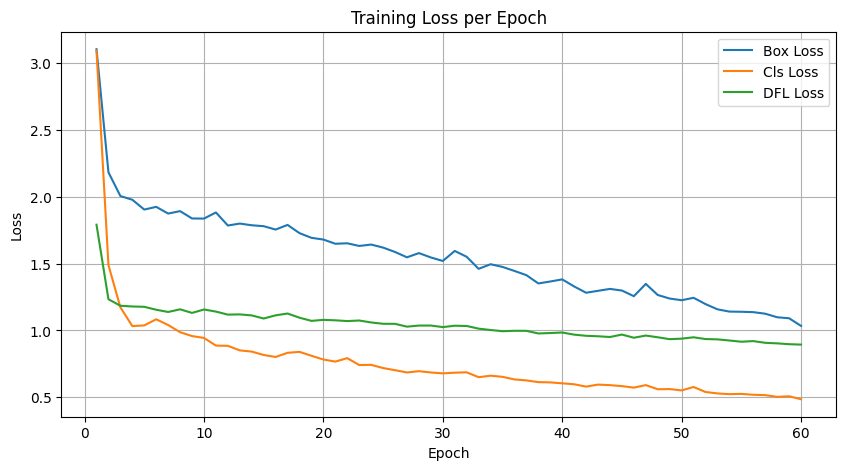

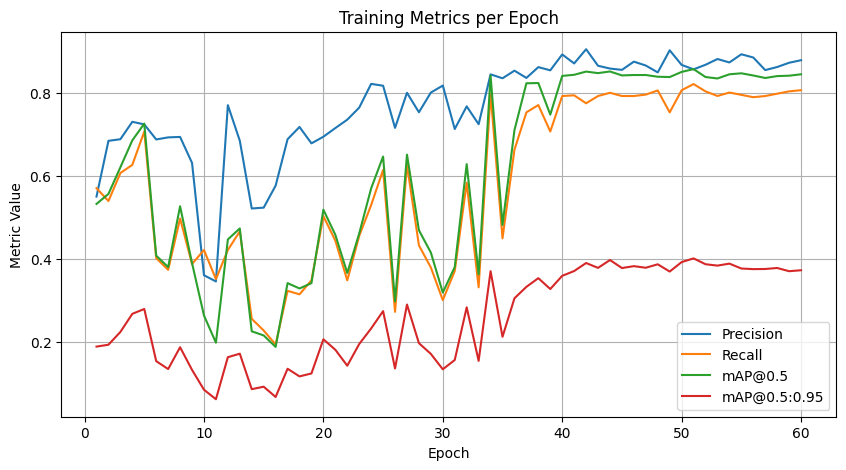

In [67]:
# Plot training results
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Path to your YOLO results CSV (update run number if different)
results_path = Path("../data/model_out/20251013/train/runs/detect/train13/results.csv")

# Load training results
df = pd.read_csv(results_path)

# Display first few rows to confirm structure
display(df.head())

# --- Plot losses ---
plt.figure(figsize=(10, 5))
plt.plot(df.index + 1, df['train/box_loss'], label='Box Loss')
plt.plot(df.index + 1, df['train/cls_loss'], label='Cls Loss')
plt.plot(df.index + 1, df['train/dfl_loss'], label='DFL Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss per Epoch')
plt.legend()
plt.grid(True)
plt.show()

# --- Plot performance metrics ---
plt.figure(figsize=(10, 5))
plt.plot(df.index + 1, df['metrics/precision(B)'], label='Precision')
plt.plot(df.index + 1, df['metrics/recall(B)'], label='Recall')
plt.plot(df.index + 1, df['metrics/mAP50(B)'], label='mAP@0.5')
plt.plot(df.index + 1, df['metrics/mAP50-95(B)'], label='mAP@0.5:0.95')
plt.xlabel('Epoch')
plt.ylabel('Metric Value')
plt.title('Training Metrics per Epoch')
plt.legend()
plt.grid(True)
plt.show()


0: 96x640 (no detections), 27.0ms
1: 96x640 3 surfers, 27.0ms
2: 96x640 6 surfers, 27.0ms
Speed: 1.8ms preprocess, 27.0ms inference, 0.3ms postprocess per image at shape (1, 3, 96, 640)


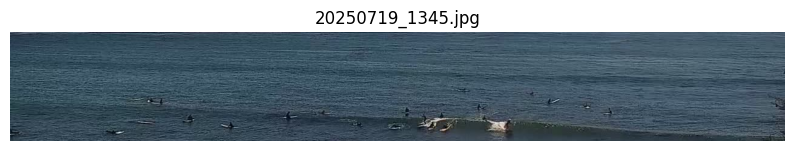

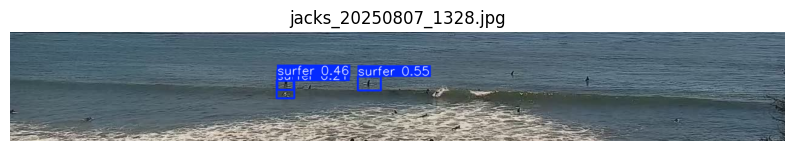

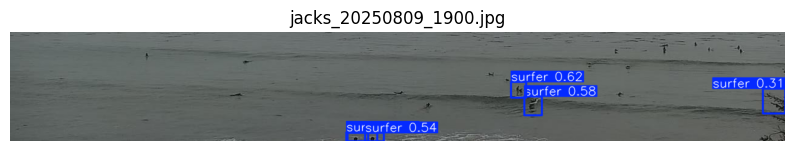

In [ ]:
# --- Preview on a few images ---
sample_images = list((data_dir / "test").glob("*.jpg"))[:3]
results = model.predict(sample_images, imgsz=640, conf=0.195)

for img_path, result in zip(sample_images, results):
    annotated = result.plot()
    plt.figure(figsize=(10, 4))
    plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    plt.title(img_path.name)
    plt.axis("off")
    plt.show()

In [ ]:
# --Function for Visualizing tiled predictions with YOLOv8 --

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2
from pathlib import Path
from ultralytics import YOLO

# --- Persistent model and generators ---
_yolo_model = None
_yolo_generators = {}

def yolo_tiled_row_generator(dataset_dir, split="val"):
    """
    Builds a generator that yields 4-tile image sets from the YOLO dataset split.
    """
    image_dir = Path(dataset_dir) / "images" / split
    image_paths = sorted(image_dir.glob("*.jpg"))
    if not image_paths:
        raise FileNotFoundError(f"No images found in {image_dir}")

    # Group tiles by shared prefix (before '_tile#')
    tile_groups = {}
    for path in image_paths:
        prefix = path.stem.split("_tile")[0]
        tile_groups.setdefault(prefix, []).append(path)

    print(f"Found {len(tile_groups)} tiled groups in '{split}' split.")
    for base_name, tiles in tile_groups.items():
        yield base_name, sorted(tiles)


def show_yolo_tiled_row(
    model_path,
    dataset_dir="../data/cvat_out_yolo_rebuilt",
    folder="val",
    conf=0.25,
    line_thickness=0.8,
    alpha=0.5
):
    """
    Runs YOLO inference and shows predictions on the next 4-tile group.

    Args:
        model_path (str): Path to YOLO model weights.
        dataset_dir (str): Path to dataset root (expects images/split/).
        folder (str): Split name ('train', 'val', 'test').
        conf (float): Confidence threshold for YOLO predictions.
        line_thickness (float): Thickness of bounding box lines.
        alpha (float): Transparency level for boxes (0.0–1.0).
    """
    global _yolo_model, _yolo_generators

    # Load YOLO model once
    if _yolo_model is None:
        print("Loading YOLO model...")
        _yolo_model = YOLO(model_path)

    # Create or reuse generator
    if folder not in _yolo_generators:
        _yolo_generators[folder] = yolo_tiled_row_generator(dataset_dir, folder)

    try:
        base_name, tile_paths = next(_yolo_generators[folder])
    except StopIteration:
        print(f"✅ Reached end of '{folder}' split. Restarting.")
        _yolo_generators[folder] = yolo_tiled_row_generator(dataset_dir, folder)
        base_name, tile_paths = next(_yolo_generators[folder])

    # --- Plot tiles ---
    fig, axes = plt.subplots(1, len(tile_paths), figsize=(16, 5))
    plt.subplots_adjust(wspace=0.05)
    fig.suptitle(f"{folder.upper()} — {base_name}", fontsize=12)
    
    for ax, img_path in zip(axes, tile_paths):
        img = cv2.imread(str(img_path))
        if img is None:
            ax.axis("off")
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        ax.axis("off")

        # Run inference
        results = _yolo_model.predict(
            source=str(img_path),
            conf=conf,
            verbose=False
        )[0]

        # Draw each box manually
        for box in results.boxes:
            xyxy = box.xyxy[0].cpu().numpy()
            x1, y1, x2, y2 = xyxy
            w, h = x2 - x1, y2 - y1

            rect = patches.Rectangle(
                (x1, y1),
                w,
                h,
                linewidth=line_thickness,
                edgecolor=(1, 0, 0, alpha),
                facecolor=(1, 0, 0, alpha * 0.2)
            )
            ax.add_patch(rect)
        
        # Get detection count
        num_detections = len(results.boxes)
        print(f"🟦 {img_path.name}: {num_detections} surfers detected")

    plt.show()



Loading YOLO model...
Found 15 tiled groups in 'val' split.
🟦 20250719_0744_tile0.jpg: 0 surfers detected
🟦 20250719_0744_tile1.jpg: 2 surfers detected
🟦 20250719_0744_tile2.jpg: 16 surfers detected
🟦 20250719_0744_tile3.jpg: 9 surfers detected
Total Surfer Count in Image: 49


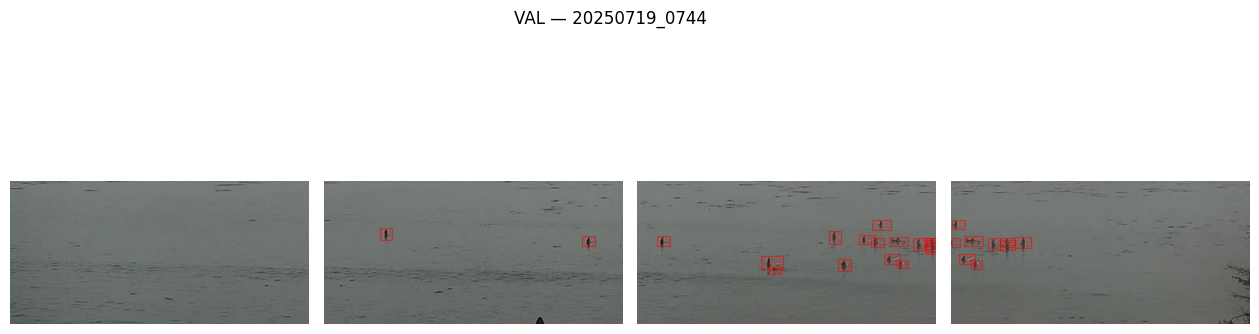

In [37]:
# -- Call function to Visualize tiled predictions -- Keep hitting enter to see next image or change to a different split
show_yolo_tiled_row(
    model_path="../data/model_out/20251013/train/runs/detect/train13/weights/best.pt",
    dataset_dir="../data/cvat_out_yolo_rebuilt",
    folder="val",
    line_thickness=0.8,
    alpha=0.5
)

In [ ]:
# Model validation using the val set
metrics = model.val()  # uses val split
print(metrics)

Ultralytics 8.3.212 🚀 Python-3.13.5 torch-2.8.0 CPU (Apple M3 Pro)
Model summary (fused): 72 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 122.6±44.7 MB/s, size: 22.5 KB)
val: Scanning /Users/jfs-m3/Documents/DS/sum-surfers/data/cvat_out_yolo_rebuilt/labels/val.cache... 60 images, 6 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 60/60 237.4Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 0.5it/s 8.2s3.8ss
                   all         60        356      0.856       0.82      0.856      0.401
Speed: 0.5ms preprocess, 130.6ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved to /Users/jfs-m3/Documents/DS/sum-surfers/code/runs/detect/val
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x1433c


0: 96x640 (no detections), 20.2ms
1: 96x640 15 surfers, 20.2ms
2: 96x640 1 surfer, 20.2ms
3: 96x640 2 surfers, 20.2ms
4: 96x640 2 surfers, 20.2ms
Speed: 0.4ms preprocess, 20.2ms inference, 0.2ms postprocess per image at shape (1, 3, 96, 640)


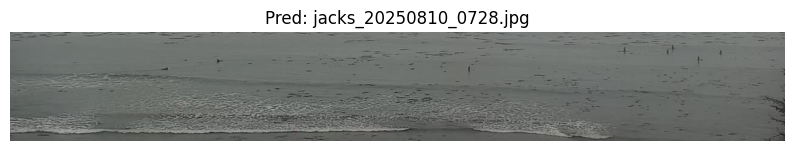

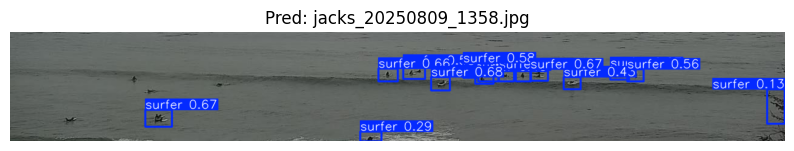

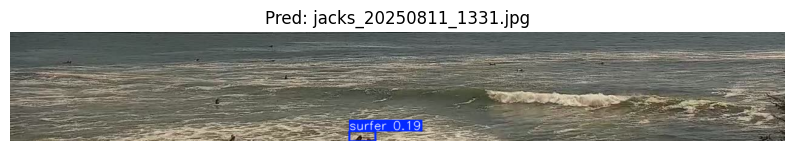

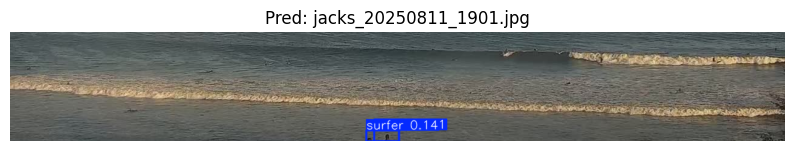

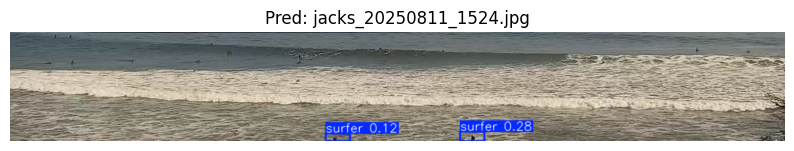

In [57]:
test_imgs = list((data_dir / "test").glob("*.jpg"))[5:10]
results = model.predict(test_imgs, imgsz=640, conf=0.1)

for img_path, result in zip(test_imgs, results):
    annotated = result.plot()
    plt.figure(figsize=(10, 4))
    plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    plt.title(f"Pred: {img_path.name}")
    plt.axis("off")
    plt.show()

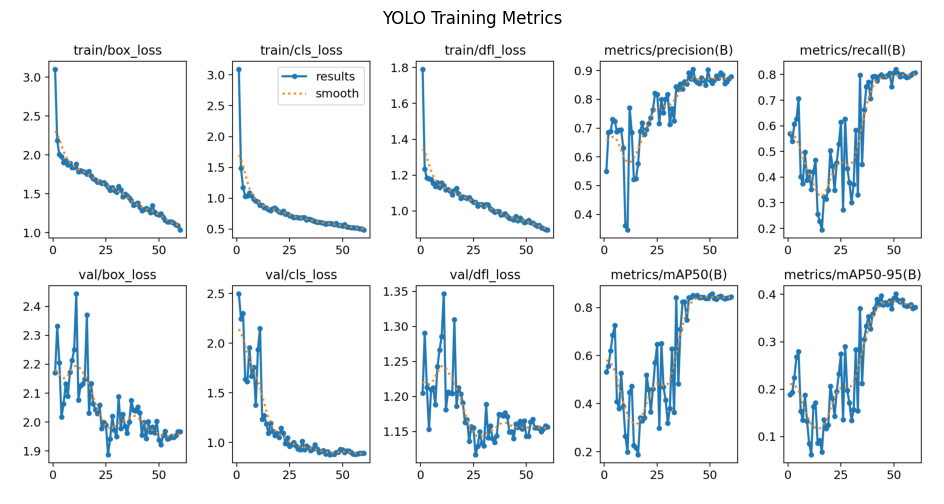

In [65]:
import matplotlib.pyplot as plt
from pathlib import Path

# Find the latest run directory
run_dir = Path("../data/model_out/20251013/train/runs/detect/train13")  # adjust if needed
results_file = run_dir / "results.png"

if results_file.exists():
    img = plt.imread(results_file)
    plt.figure(figsize=(12, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.title("YOLO Training Metrics")
    plt.show()
else:
    print("results.png not found")

In [ ]:
model.save("surfer_detector.pt")